In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
#only have to use two species for output so we will remove the entries with cspecies setosa
df = df[df['species']!='setosa']
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [4]:
#checking for null values in dataset
df.isnull().sum() #no null values 

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
df['species'].map({'versicolor': 0,'virginica':1})
#spiliting the dataset into features and labels
X = df.iloc[:,:-1];
y =df.iloc[:,-1]
print(X)
print(y)

     sepal_length  sepal_width  petal_length  petal_width
50            7.0          3.2           4.7          1.4
51            6.4          3.2           4.5          1.5
52            6.9          3.1           4.9          1.5
53            5.5          2.3           4.0          1.3
54            6.5          2.8           4.6          1.5
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[100 rows x 4 columns]
50     versicolor
51     versicolor
52     versicolor
53     versicolor
54     versicolor
          ...    
145     virginica
146     virginica
147     virginica
148     virginica
149     virginica
Name: species, Length: 100, dtype: object


In [6]:
from sklearn.model_selection import train_test_split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)   

In [8]:
print(X_train.head())
print(X_test.head())

     sepal_length  sepal_width  petal_length  petal_width
65            6.7          3.1           4.4          1.4
102           7.1          3.0           5.9          2.1
110           6.5          3.2           5.1          2.0
116           6.5          3.0           5.5          1.8
118           7.7          2.6           6.9          2.3
     sepal_length  sepal_width  petal_length  petal_width
107           7.3          2.9           6.3          1.8
127           6.1          3.0           4.9          1.8
113           5.7          2.5           5.0          2.0
101           5.8          2.7           5.1          1.9
57            4.9          2.4           3.3          1.0


In [9]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

In [10]:
from sklearn.model_selection import GridSearchCV #it will take the different parameters given by us and find the most optimal paramter that gives good accuracy
parameter = {'penalty':['l1','l2','elasticnet'],'C':[1,2,3,4,5,6,7,90],'max_iter':[100,200,400]}

In [11]:
classifier_regressor = GridSearchCV(classifier,param_grid=parameter,scoring='accuracy',cv=5)
classifier_regressor.fit(X_train,y_train)

C:\Users\amanv\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
240 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\amanv\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\amanv\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\amanv\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver 

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 7, 90],
                         'max_iter': [100, 200, 400],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy')

In [12]:
print(classifier_regressor.best_params_)

{'C': 90, 'max_iter': 100, 'penalty': 'l2'}


In [13]:
print(classifier_regressor.best_score_)

0.95


In [14]:
from sklearn.metrics import classification_report,accuracy_score


In [15]:
y_pred  = classifier_regressor.predict(X_test)
print(y_pred)

['virginica' 'virginica' 'virginica' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'versicolor' 'versicolor'
 'virginica' 'versicolor' 'versicolor' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'virginica' 'virginica']


In [16]:
score  = accuracy_score(y_pred,y_test)
print(score)

0.95


In [17]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



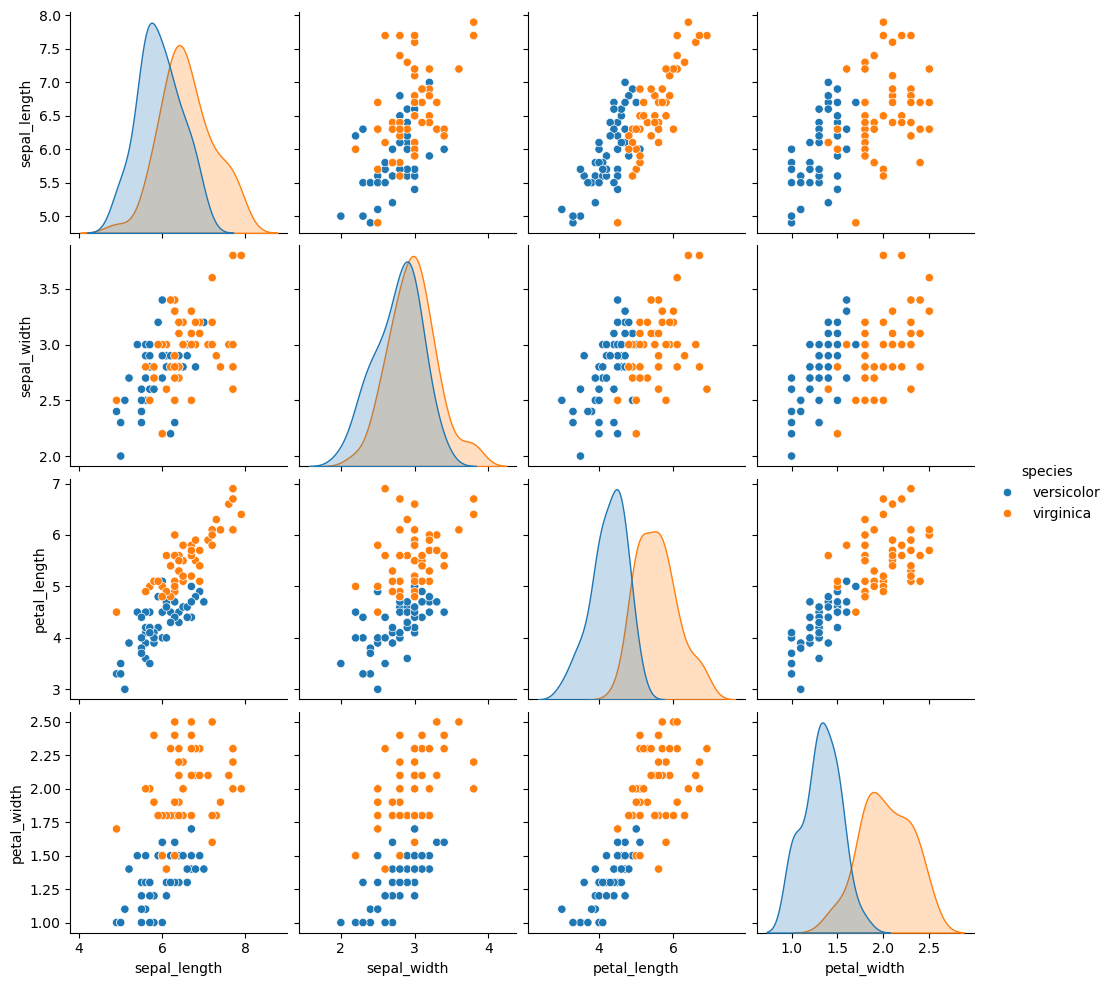

In [18]:
sns.pairplot(df,hue='species')